# Notebook 06: Model Export & System Demo

**Purpose**: 
1. Train the autoencoder and save model artifacts to `models/` for use by the detection system
2. Demonstrate the system working end-to-end from Python code

**Output**: 
- `models/autoencoder.keras` — trained TensorFlow autoencoder
- `models/scaler.pkl` — fitted StandardScaler (trained on healthy data)
- `models/config.json` — threshold, feature names, and pipeline parameters

In [ ]:
# --- Colab Setup (run this cell first if using Google Colab) ---
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/cattle-anomaly-detection'):
        !git clone https://github.com/dimvsh/cattle-anomaly-detection.git /content/cattle-anomaly-detection
    os.chdir('/content/cattle-anomaly-detection/notebooks')
    !pip install -q -r /content/cattle-anomaly-detection/requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally.")

## Part 1: Train and Export Model Artifacts

In [1]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Load daily features
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'daily_features.csv'), parse_dates=['date'])
df['is_sick'] = df['is_sick'].fillna(0).astype(int)

feature_cols = ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']
df['max_absence_hours'] = df['max_absence_hours'].fillna(df['max_absence_hours'].median())

# Temporal split (same as notebook 04)
all_dates = sorted(df['date'].unique())
split_idx = int(len(all_dates) * 0.7)
train_dates = all_dates[:split_idx]

train_df = df[df['date'].isin(train_dates)]
train_healthy = train_df[train_df['is_sick'] == 0]

# Fit scaler on training healthy data
scaler = StandardScaler()
scaler.fit(train_healthy[feature_cols])
X_train_healthy = scaler.transform(train_healthy[feature_cols])

print(f'Training data: {len(train_healthy)} healthy animal-days from {len(train_dates)} days')
print(f'Features: {feature_cols}')

Training data: 492 healthy animal-days from 18 days
Features: ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']


In [2]:
# Build and train autoencoder (same architecture as notebook 04)
input_dim = len(feature_cols)

encoder = keras.Sequential([
    keras.layers.Dense(3, activation='relu', input_shape=(input_dim,)),
    keras.layers.Dense(2, activation='relu')
], name='encoder')

decoder = keras.Sequential([
    keras.layers.Dense(3, activation='relu', input_shape=(2,)),
    keras.layers.Dense(input_dim, activation='linear')
], name='decoder')

autoencoder = keras.Sequential([encoder, decoder], name='autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

history = autoencoder.fit(
    X_train_healthy, X_train_healthy,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=0
)

print(f'Final training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 0.6295
Final validation loss: 0.6389


In [3]:
# Compute threshold (95th percentile of training reconstruction errors)
train_mse = np.mean(
    (X_train_healthy - autoencoder.predict(X_train_healthy, verbose=0)) ** 2, axis=1
)
threshold = float(np.percentile(train_mse, 95))

print(f'Training MSE — mean: {train_mse.mean():.4f}, std: {train_mse.std():.4f}')
print(f'Threshold (95th percentile): {threshold:.4f}')

Training MSE — mean: 0.6298, std: 0.9507
Threshold (95th percentile): 2.3214


In [4]:
# Save all artifacts

# 1. Save autoencoder model
model_path = os.path.join(MODEL_DIR, 'autoencoder.keras')
autoencoder.save(model_path)
print(f'Saved model: {model_path}')

# 2. Save scaler
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'Saved scaler: {scaler_path}')

# 3. Save config
config = {
    'feature_cols': feature_cols,
    'threshold': threshold,
    'bout_gap_threshold': 60,
    'max_duration_sec': 1800,
    'architecture': '4-3-2-3-4',
    'training_samples': int(len(train_healthy)),
    'training_period': f'{train_dates[0].date()} to {train_dates[-1].date()}',
    'threshold_percentile': 95
}
config_path = os.path.join(MODEL_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved config: {config_path}')
print(f'\nConfig contents:')
print(json.dumps(config, indent=2))

Saved model: /Users/dimvsh/Downloads/Dana Thesis/project/models/autoencoder.keras
Saved scaler: /Users/dimvsh/Downloads/Dana Thesis/project/models/scaler.pkl
Saved config: /Users/dimvsh/Downloads/Dana Thesis/project/models/config.json

Config contents:
{
  "feature_cols": [
    "total_daily_duration",
    "visit_count",
    "avg_visit_duration",
    "max_absence_hours"
  ],
  "threshold": 2.3213777796927264,
  "bout_gap_threshold": 60,
  "max_duration_sec": 1800,
  "architecture": "4-3-2-3-4",
  "training_samples": 492,
  "training_period": "2024-10-11 to 2024-10-29",
  "threshold_percentile": 95
}


## Part 2: System Demo — End-to-End Pipeline

Demonstrate that the `src` package can process raw scanner data and produce anomaly results, matching the notebook analysis.

In [5]:
import sys
sys.path.insert(0, PROJECT_DIR)

from src.pipeline import run_pipeline

# Run the system on the same data used in notebooks
scanner_path = os.path.join(PROCESSED_DIR, 'scanner_data_clean.csv')
results, summary = run_pipeline(scanner_path, model_dir=MODEL_DIR)

print('Pipeline Summary:')
for key, val in summary.items():
    if key != 'cleaning':
        print(f'  {key}: {val}')

print(f'\nResults shape: {results.shape}')
print(f'Columns: {list(results.columns)}')

Pipeline Summary:
  loaded_sessions: 32118
  bouts: 5436
  animal_days: 793
  animals: 30
  days: 27
  anomalies_flagged: 32
  anomaly_rate: 0.0403530895334174

Results shape: (793, 9)
Columns: ['tag_short', 'date', 'total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_sec', 'max_absence_hours', 'ae_score', 'ae_anomaly']


In [6]:
# Show flagged animals
flagged = results[results['ae_anomaly'] == 1]
print(f'Anomalies flagged: {len(flagged)} animal-days')
print(f'\nFlagged animals:')

animal_flags = flagged.groupby('tag_short').agg(
    anomaly_days=('ae_anomaly', 'sum'),
    max_score=('ae_score', 'max')
).reset_index()

total_days = results.groupby('tag_short')['ae_anomaly'].count()
animal_flags = animal_flags.merge(total_days.rename('total_days'), left_on='tag_short', right_index=True)
animal_flags = animal_flags.sort_values('anomaly_days', ascending=False)

for _, row in animal_flags.iterrows():
    print(f"  Animal {row['tag_short']}: {row['anomaly_days']:.0f}/{row['total_days']} days, "
          f"max score={row['max_score']:.2f}")

Anomalies flagged: 32 animal-days

Flagged animals:
  Animal 1149.0: 6/22.0 days, max score=8.26
  Animal 1127.0: 5/27.0 days, max score=6.57
  Animal 1101.0: 2/27.0 days, max score=2.85
  Animal 1112.0: 2/27.0 days, max score=4.35
  Animal 1145.0: 2/27.0 days, max score=4.49
  Animal 1122.0: 2/27.0 days, max score=3.99
  Animal 1140.0: 2/26.0 days, max score=4.09
  Animal 1138.0: 1/27.0 days, max score=6.96
  Animal 1143.0: 1/27.0 days, max score=2.89
  Animal 1139.0: 1/27.0 days, max score=4.57
  Animal 1136.0: 1/27.0 days, max score=3.08
  Animal 1137.0: 1/27.0 days, max score=3.99
  Animal 1106.0: 1/27.0 days, max score=6.58
  Animal 1135.0: 1/27.0 days, max score=2.51
  Animal 1124.0: 1/27.0 days, max score=4.69
  Animal 1117.0: 1/26.0 days, max score=2.37
  Animal 1113.0: 1/27.0 days, max score=3.36
  Animal 1150.0: 1/27.0 days, max score=5.43


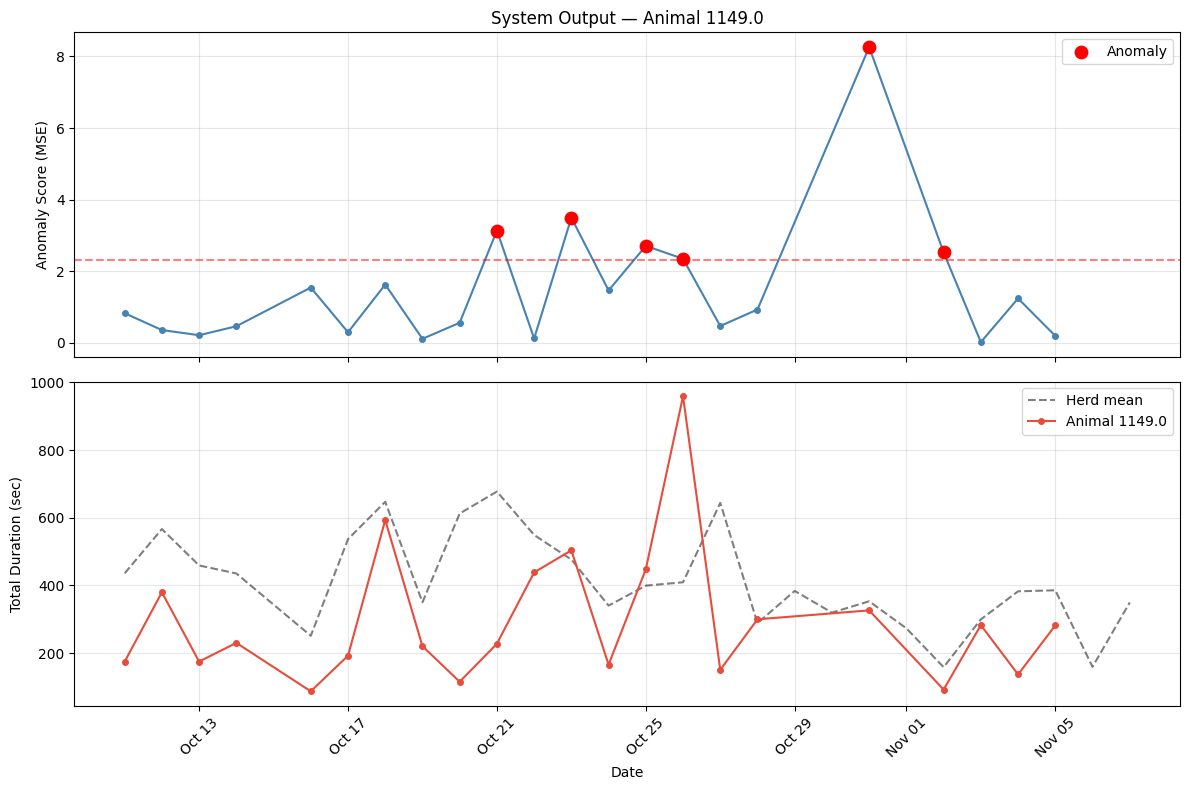


System demo complete. The detection system is ready for use.
  CLI:       python detect.py --input <scanner_data.csv>
  Dashboard: streamlit run app.py


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Visualize the top flagged animal
if len(animal_flags) > 0:
    top_animal = animal_flags.iloc[0]['tag_short']
    animal_data = results[results['tag_short'] == top_animal].sort_values('date')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Anomaly score
    ax1.plot(animal_data['date'], animal_data['ae_score'], '-o', color='steelblue', markersize=4)
    anom = animal_data[animal_data['ae_anomaly'] == 1]
    ax1.scatter(anom['date'], anom['ae_score'], color='red', s=80, zorder=5, label='Anomaly')
    ax1.axhline(summary.get('threshold', threshold), color='red', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Anomaly Score (MSE)')
    ax1.set_title(f'System Output — Animal {top_animal}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Total drinking duration
    herd_mean = results.groupby('date')['total_daily_duration'].mean()
    ax2.plot(herd_mean.index, herd_mean.values, 'k--', alpha=0.5, label='Herd mean')
    ax2.plot(animal_data['date'], animal_data['total_daily_duration'], '-o',
             color='#e74c3c', markersize=4, label=f'Animal {top_animal}')
    ax2.set_ylabel('Total Duration (sec)')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

print('\nSystem demo complete. The detection system is ready for use.')
print('  CLI:       python detect.py --input <scanner_data.csv>')
print('  Dashboard: streamlit run app.py')